# Multi-Coin Crypto Forecasting Notebook

This notebook builds a shared deep learning model that learns from many cryptocurrencies at once and then evaluates how well it can predict the next-day return and the next-day close for a selected coin such as BTCUSDT.

## What this notebook does

1. Downloads daily OHLCV data from the public Binance REST API
2. Selects the most liquid USDT pairs
3. Engineers rolling features for every coin
4. Builds a panel dataset across many coins
5. Trains a Keras model on all coins together
6. Evaluates the model on one selected target coin
7. Visualizes:
   - market coverage
   - training curves
   - actual vs predicted returns
   - reconstructed price paths
   - rolling directional accuracy
   - prediction scatter plots

## Practical note

This notebook is intentionally written as a single run, end-to-end workflow with detailed documentation and plots.
Training on many symbols can take time. The defaults are chosen to be ambitious but still realistic for a home machine.

You only need to execute the cells from top to bottom.

In [1]:
%pip -q install pandas numpy matplotlib scikit-learn requests tqdm tensorflow joblib

^C
Note: you may need to restart the kernel to use updated packages.


## Configuration

You can change the values below if you want to trade off:
- more coins vs faster runtime
- longer history vs smaller memory use
- more epochs vs faster experiments

In [3]:
import math
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests

from tqdm.auto import tqdm
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (12, 6)

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

MAX_SYMBOLS = 150
LOOKBACK_DAYS = 30
HISTORY_LIMIT = 500
MIN_HISTORY = 220
TARGET_SYMBOL = "BTCUSDT"
EPOCHS = 30
BATCH_SIZE = 512

TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

assert abs(TRAIN_RATIO + VAL_RATIO + TEST_RATIO - 1.0) < 1e-9

BINANCE_BASE = "https://api.binance.com"

print("TensorFlow version:", tf.__version__)
print("Target symbol:", TARGET_SYMBOL)
print("Maximum symbols:", MAX_SYMBOLS)

I0000 00:00:1773429611.686585   27799 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1773429611.745851   27799 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1773429616.394934   27799 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1773429627.000074   27799 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

TensorFlow version: 2.21.0
Target symbol: BTCUSDT
Maximum symbols: 150


## Data download helpers

We use the public Binance REST API:
- exchangeInfo to discover tradable spot symbols
- ticker/24hr to rank symbols by liquidity
- klines to download daily candles

The selection strategy is simple and practical:
- keep USDT spot pairs
- exclude leveraged tokens and stablecoin bases
- sort by 24-hour quote volume
- keep the top MAX_SYMBOLS

In [4]:
def get_exchange_info():
    url = f"{BINANCE_BASE}/api/v3/exchangeInfo"
    r = requests.get(url, timeout=30)
    r.raise_for_status()
    return r.json()

def get_24h_tickers():
    url = f"{BINANCE_BASE}/api/v3/ticker/24hr"
    r = requests.get(url, timeout=30)
    r.raise_for_status()
    return r.json()

def is_clean_usdt_spot_symbol(symbol_row):
    symbol = symbol_row["symbol"]
    status = symbol_row.get("status")
    quote = symbol_row.get("quoteAsset")
    base = symbol_row.get("baseAsset")
    spot_allowed = symbol_row.get("isSpotTradingAllowed", False)

    banned_suffixes = ("UPUSDT", "DOWNUSDT", "BULLUSDT", "BEARUSDT")
    stable_bases = {"USDC", "FDUSD", "TUSD", "USDP", "BUSD", "DAI", "USDS", "EURI", "EUR"}

    if quote != "USDT":
        return False
    if status != "TRADING":
        return False
    if not spot_allowed:
        return False
    if symbol.endswith(banned_suffixes):
        return False
    if base in stable_bases:
        return False
    return True

def get_top_symbols(max_symbols=MAX_SYMBOLS):
    exchange = get_exchange_info()
    tickers = pd.DataFrame(get_24h_tickers())

    tradable = pd.DataFrame(exchange["symbols"])
    tradable = tradable[tradable.apply(is_clean_usdt_spot_symbol, axis=1)].copy()

    tickers["quoteVolume"] = pd.to_numeric(tickers["quoteVolume"], errors="coerce")
    tickers["volume"] = pd.to_numeric(tickers["volume"], errors="coerce")
    tickers = tickers[["symbol", "quoteVolume", "volume"]]

    merged = tradable.merge(tickers, on="symbol", how="left")
    merged["quoteVolume"] = merged["quoteVolume"].fillna(0.0)
    merged = merged.sort_values("quoteVolume", ascending=False)

    selected = merged["symbol"].head(max_symbols).tolist()

    if TARGET_SYMBOL not in selected and TARGET_SYMBOL in merged["symbol"].values:
        selected = [TARGET_SYMBOL] + [s for s in selected if s != TARGET_SYMBOL]
        selected = selected[:max_symbols]

    return selected, merged

def fetch_daily_klines(symbol, limit=HISTORY_LIMIT):
    url = f"{BINANCE_BASE}/api/v3/klines"
    params = {"symbol": symbol, "interval": "1d", "limit": limit}
    r = requests.get(url, params=params, timeout=30)
    r.raise_for_status()
    raw = r.json()

    cols = [
        "open_time", "open", "high", "low", "close", "volume",
        "close_time", "quote_asset_volume", "num_trades",
        "taker_buy_base_volume", "taker_buy_quote_volume", "ignore"
    ]
    df = pd.DataFrame(raw, columns=cols)

    numeric_cols = [
        "open", "high", "low", "close", "volume",
        "quote_asset_volume", "taker_buy_base_volume", "taker_buy_quote_volume"
    ]
    for c in numeric_cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    df["open_time"] = pd.to_datetime(df["open_time"], unit="ms", utc=True)
    df["close_time"] = pd.to_datetime(df["close_time"], unit="ms", utc=True)
    df["symbol"] = symbol
    return df

symbols, symbol_table = get_top_symbols(MAX_SYMBOLS)
print(f"Selected {len(symbols)} symbols.")
print(symbols[:20], "...")

Selected 150 symbols.
['BTCUSDT', 'ETHUSDT', 'SOLUSDT', 'XRPUSDT', 'TRUMPUSDT', 'DOGEUSDT', 'USD1USDT', 'BNBUSDT', 'NIGHTUSDT', 'PAXGUSDT', 'TAOUSDT', 'SUIUSDT', 'PEPEUSDT', 'OPNUSDT', 'ADAUSDT', 'ZECUSDT', 'NEARUSDT', 'LINKUSDT', 'PIXELUSDT', 'RENDERUSDT'] ...


In [5]:
all_frames = []
failed_symbols = []

for symbol in tqdm(symbols, desc="Downloading daily candles"):
    try:
        df_sym = fetch_daily_klines(symbol, limit=HISTORY_LIMIT)
        if len(df_sym) >= MIN_HISTORY:
            all_frames.append(df_sym)
        else:
            failed_symbols.append((symbol, f"Too short: {len(df_sym)} rows"))
        time.sleep(0.02)
    except Exception as e:
        failed_symbols.append((symbol, str(e)[:120]))

raw_df = pd.concat(all_frames, ignore_index=True).sort_values(["symbol", "open_time"]).reset_index(drop=True)

print("Downloaded symbols:", raw_df["symbol"].nunique())
print("Rows:", len(raw_df))
print("Failures / skipped:", len(failed_symbols))
raw_df.head()

Downloaded symbols: 122
Rows: 58071
Failures / skipped: 28


,open_time,open,high,low,close,volume,close_time,quote_asset_volume,num_trades,taker_buy_base_volume,taker_buy_quote_volume,ignore,symbol
0,2024-10-30 00:00:00+00:00,0.000263,0.000263,0.000248,0.000256,1.089263e+11,2024-10-30 23:59:59.999000+00:00,2.804817e+07,268808,5.183903e+10,1.334952e+07,0,1000SATSUSDT
1,2024-10-31 00:00:00+00:00,0.000256,0.000257,0.000235,0.000238,1.011213e+11,2024-10-31 23:59:59.999000+00:00,2.497048e+07,238355,4.645522e+10,1.147245e+07,0,1000SATSUSDT
2,2024-11-01 00:00:00+00:00,0.000238,0.000241,0.000222,0.000228,1.186245e+11,2024-11-01 23:59:59.999000+00:00,2.759286e+07,276502,5.567942e+10,1.296016e+07,0,1000SATSUSDT
3,2024-11-02 00:00:00+00:00,0.000228,0.000233,0.000221,0.000224,7.419374e+10,2024-11-02 23:59:59.999000+00:00,1.679592e+07,144638,3.375926e+10,7.650781e+06,0,1000SATSUSDT
4,2024-11-03 00:00:00+00:00,0.000224,0.000226,0.000193,0.000203,2.022330e+11,2024-11-03 23:59:59.999000+00:00,4.172113e+07,334716,9.361495e+10,1.927978e+07,0,1000SATSUSDT


## Basic market coverage plots

           rows                first_date                 last_date  \
symbol                                                                
BTCUSDT     500 2024-10-30 00:00:00+00:00 2026-03-13 00:00:00+00:00   
ETHUSDT     500 2024-10-30 00:00:00+00:00 2026-03-13 00:00:00+00:00   
SOLUSDT     500 2024-10-30 00:00:00+00:00 2026-03-13 00:00:00+00:00   
XRPUSDT     500 2024-10-30 00:00:00+00:00 2026-03-13 00:00:00+00:00   
DOGEUSDT    500 2024-10-30 00:00:00+00:00 2026-03-13 00:00:00+00:00   
BNBUSDT     500 2024-10-30 00:00:00+00:00 2026-03-13 00:00:00+00:00   
PEPEUSDT    500 2024-10-30 00:00:00+00:00 2026-03-13 00:00:00+00:00   
SUIUSDT     500 2024-10-30 00:00:00+00:00 2026-03-13 00:00:00+00:00   
ADAUSDT     500 2024-10-30 00:00:00+00:00 2026-03-13 00:00:00+00:00   
TRUMPUSDT   419 2025-01-19 00:00:00+00:00 2026-03-13 00:00:00+00:00   

             last_close  total_quote_volume  
symbol                                       
BTCUSDT    71165.410000        1.114517e+12  
ETHUSDT  

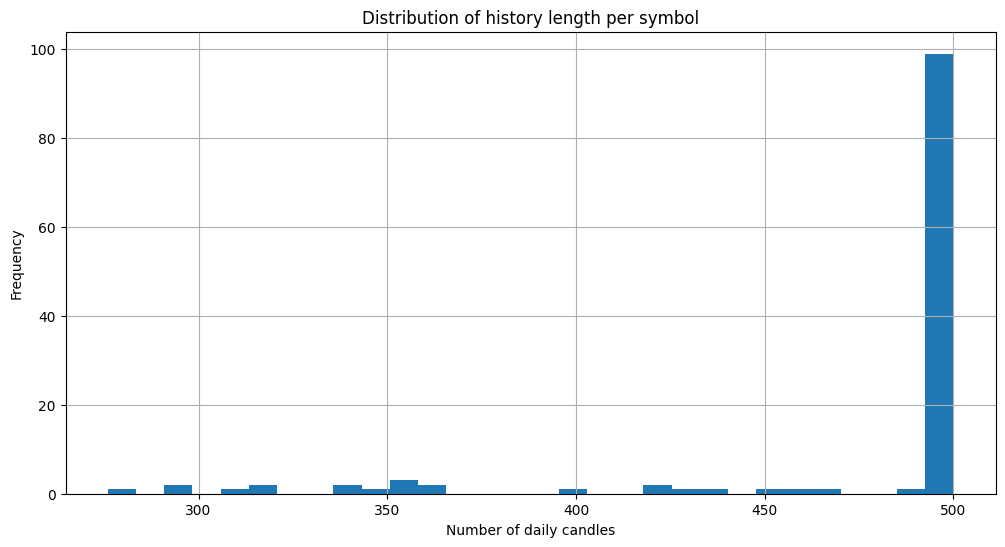

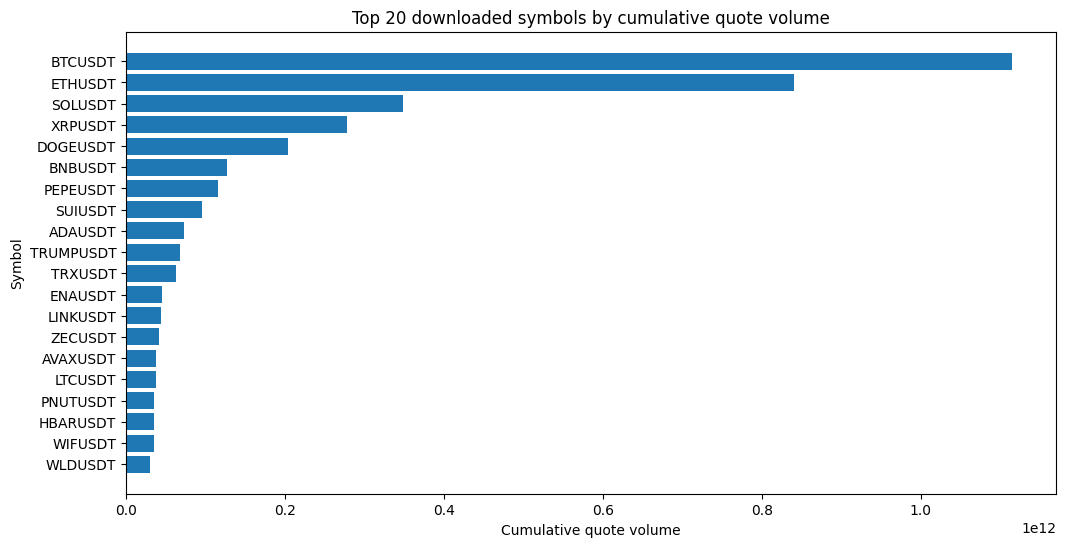

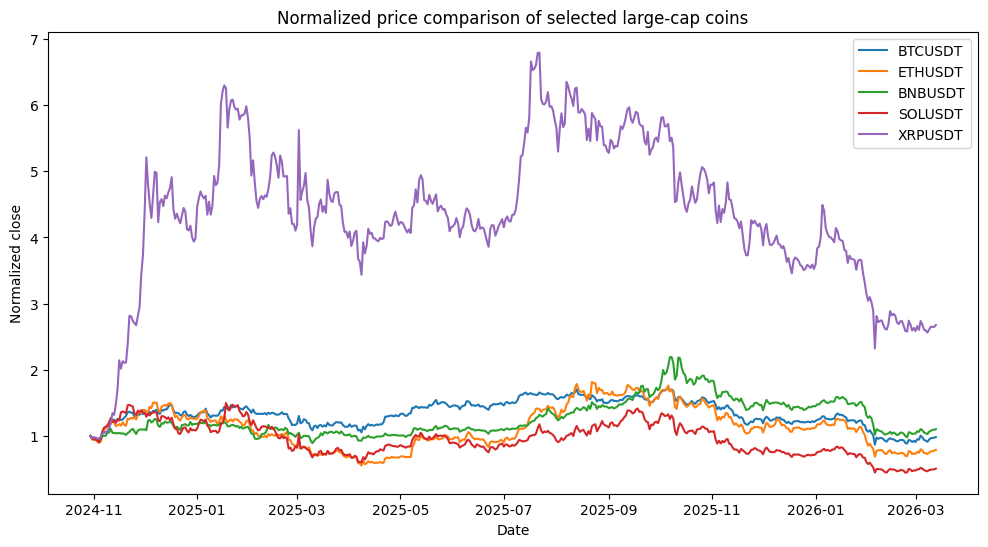

In [6]:
coverage = raw_df.groupby("symbol").agg(
    rows=("close", "size"),
    first_date=("open_time", "min"),
    last_date=("open_time", "max"),
    last_close=("close", "last"),
    total_quote_volume=("quote_asset_volume", "sum")
).sort_values("total_quote_volume", ascending=False)

print(coverage.head(10))

fig, ax = plt.subplots()
coverage["rows"].hist(ax=ax, bins=30)
ax.set_title("Distribution of history length per symbol")
ax.set_xlabel("Number of daily candles")
ax.set_ylabel("Frequency")
plt.show()

top_liquidity = coverage.head(20).sort_values("total_quote_volume")
fig, ax = plt.subplots()
ax.barh(top_liquidity.index, top_liquidity["total_quote_volume"])
ax.set_title("Top 20 downloaded symbols by cumulative quote volume")
ax.set_xlabel("Cumulative quote volume")
ax.set_ylabel("Symbol")
plt.show()

sample_symbols = [s for s in ["BTCUSDT", "ETHUSDT", "BNBUSDT", "SOLUSDT", "XRPUSDT"] if s in raw_df["symbol"].unique()]
fig, ax = plt.subplots()
for s in sample_symbols:
    tmp = raw_df[raw_df["symbol"] == s].copy().sort_values("open_time")
    normalized = tmp["close"] / tmp["close"].iloc[0]
    ax.plot(tmp["open_time"], normalized, label=s)
ax.set_title("Normalized price comparison of selected large-cap coins")
ax.set_xlabel("Date")
ax.set_ylabel("Normalized close")
ax.legend()
plt.show()

## Feature engineering

The target is:

**next-day return = (close[t+1] / close[t]) - 1**

This is more stable than predicting the absolute next-day price directly.

In [7]:
def engineer_features(df):
    df = df.sort_values(["symbol", "open_time"]).copy()
    g = df.groupby("symbol", group_keys=False)

    df["log_close"] = np.log(df["close"])
    df["ret_1"] = g["close"].pct_change(1)
    df["ret_3"] = g["close"].pct_change(3)
    df["ret_7"] = g["close"].pct_change(7)
    df["ret_14"] = g["close"].pct_change(14)

    df["log_ret_1"] = g["log_close"].diff(1)
    df["vol_chg_1"] = g["volume"].pct_change(1)

    df["hl_range"] = (df["high"] - df["low"]) / df["close"]
    df["oc_range"] = (df["close"] - df["open"]) / df["open"]

    for w in [5, 10, 20, 30]:
        df[f"sma_{w}"] = g["close"].transform(lambda x: x.rolling(w).mean())
        df[f"std_{w}"] = g["ret_1"].transform(lambda x: x.rolling(w).std())
        df[f"vol_sma_{w}"] = g["volume"].transform(lambda x: x.rolling(w).mean())

    df["dist_sma_5"] = (df["close"] / df["sma_5"]) - 1
    df["dist_sma_10"] = (df["close"] / df["sma_10"]) - 1
    df["dist_sma_20"] = (df["close"] / df["sma_20"]) - 1
    df["dist_sma_30"] = (df["close"] / df["sma_30"]) - 1

    df["vol_rel_5"] = (df["volume"] / df["vol_sma_5"]) - 1
    df["vol_rel_20"] = (df["volume"] / df["vol_sma_20"]) - 1

    df["target_next_ret"] = g["close"].shift(-1) / df["close"] - 1
    df["next_close"] = g["close"].shift(-1)

    return df

feat_df = engineer_features(raw_df)

feature_cols = [
    "ret_1", "ret_3", "ret_7", "ret_14",
    "log_ret_1", "vol_chg_1",
    "hl_range", "oc_range",
    "std_5", "std_10", "std_20", "std_30",
    "dist_sma_5", "dist_sma_10", "dist_sma_20", "dist_sma_30",
    "vol_rel_5", "vol_rel_20"
]

needed = ["symbol", "open_time", "close"] + feature_cols + ["target_next_ret", "next_close"]
feat_df = feat_df[needed].replace([np.inf, -np.inf], np.nan)
feat_df = feat_df.dropna().reset_index(drop=True)

print("Feature rows after cleaning:", len(feat_df))
print("Symbols remaining:", feat_df["symbol"].nunique())
feat_df.head()

Feature rows after cleaning: 54289
Symbols remaining: 122


,symbol,open_time,close,ret_1,ret_3,ret_7,ret_14,log_ret_1,vol_chg_1,hl_range,...,std_20,std_30,dist_sma_5,dist_sma_10,dist_sma_20,dist_sma_30,vol_rel_5,vol_rel_20,target_next_ret,next_close
0,1000SATSUSDT,2024-11-29 00:00:00+00:00,0.000270,0.021534,0.124324,0.086817,0.073442,0.021305,-0.321591,0.062500,...,0.051535,0.062097,0.055920,0.079958,0.058338,0.095550,-0.227777,-0.377114,0.087648,0.000294
1,1000SATSUSDT,2024-11-30 00:00:00+00:00,0.000294,0.087648,0.174052,0.162910,0.170780,0.084018,0.629594,0.171370,...,0.052704,0.062282,0.113846,0.144714,0.147819,0.182549,0.264374,0.036075,-0.041823,0.000282
2,1000SATSUSDT,2024-12-01 00:00:00+00:00,0.000282,-0.041823,0.064601,0.113394,0.176127,-0.042722,0.075079,0.144074,...,0.051404,0.062377,0.034888,0.079239,0.103389,0.125055,0.304012,0.132486,-0.037260,0.000271
3,1000SATSUSDT,2024-12-02 00:00:00+00:00,0.000271,-0.037260,0.003328,0.066850,0.053183,-0.037972,-0.280614,0.132694,...,0.045965,0.062749,-0.018665,0.030149,0.061279,0.076388,-0.114432,-0.130394,0.164762,0.000316
4,1000SATSUSDT,2024-12-03 00:00:00+00:00,0.000316,0.164762,0.074464,0.313929,0.304168,0.152517,1.742773,0.245253,...,0.058618,0.065883,0.102121,0.171803,0.224213,0.235276,0.899613,1.393901,-0.038924,0.000304


## Chronological split

In [8]:
split_frames = []

for symbol, grp in feat_df.groupby("symbol"):
    grp = grp.sort_values("open_time").reset_index(drop=True)
    n = len(grp)
    train_end = int(n * TRAIN_RATIO)
    val_end = int(n * (TRAIN_RATIO + VAL_RATIO))

    grp.loc[:train_end - 1, "split"] = "train"
    grp.loc[train_end:val_end - 1, "split"] = "val"
    grp.loc[val_end:, "split"] = "test"

    split_frames.append(grp)

split_df = pd.concat(split_frames, ignore_index=True)

train_mask = split_df["split"] == "train"
val_mask = split_df["split"] == "val"
test_mask = split_df["split"] == "test"

scaler = StandardScaler()
split_df.loc[train_mask, feature_cols] = scaler.fit_transform(split_df.loc[train_mask, feature_cols])
split_df.loc[val_mask, feature_cols] = scaler.transform(split_df.loc[val_mask, feature_cols])
split_df.loc[test_mask, feature_cols] = scaler.transform(split_df.loc[test_mask, feature_cols])

split_df.head()

,symbol,open_time,close,ret_1,ret_3,ret_7,ret_14,log_ret_1,vol_chg_1,hl_range,...,std_30,dist_sma_5,dist_sma_10,dist_sma_20,dist_sma_30,vol_rel_5,vol_rel_20,target_next_ret,next_close,split
0,1000SATSUSDT,2024-11-29 00:00:00+00:00,0.000270,0.372501,1.194875,0.577510,0.361804,0.401386,-0.451517,-0.326959,...,0.230522,0.937498,0.921020,0.538652,0.661770,-0.505053,-0.512963,0.087648,0.000294,train
1,1000SATSUSDT,2024-11-30 00:00:00+00:00,0.000294,1.450442,1.659453,1.039315,0.771857,1.429758,0.378177,0.980466,...,0.237981,1.822986,1.574760,1.150988,1.133409,0.551359,0.029979,-0.041823,0.000282,train
2,1000SATSUSDT,2024-12-01 00:00:00+00:00,0.000282,-0.660476,0.636915,0.738805,0.794381,-0.648553,-0.105512,0.652662,...,0.241835,0.615993,0.913753,0.846944,0.821722,0.636443,0.156666,-0.037260,0.000271,train
3,1000SATSUSDT,2024-12-02 00:00:00+00:00,0.000271,-0.586096,0.064474,0.456335,0.276461,-0.570663,-0.415774,0.516007,...,0.256850,-0.202634,0.418169,0.558778,0.557889,-0.261755,-0.188766,0.164762,0.000316,train
4,1000SATSUSDT,2024-12-03 00:00:00+00:00,0.000316,2.707733,0.729060,1.955837,1.333776,2.553030,1.349175,1.867726,...,0.383407,1.643739,1.848229,1.673763,1.419249,1.914913,1.814201,-0.038924,0.000304,train


## Sequence builder

In [9]:
def build_sequences(df, feature_cols, lookback=30):
    X, y, meta = [], [], []

    for symbol, grp in df.groupby("symbol"):
        grp = grp.sort_values("open_time").reset_index(drop=True)

        values = grp[feature_cols].values.astype(np.float32)
        targets = grp["target_next_ret"].values.astype(np.float32)

        dates = grp["open_time"].values
        closes = grp["close"].values.astype(np.float32)
        next_closes = grp["next_close"].values.astype(np.float32)
        splits = grp["split"].values

        for i in range(lookback, len(grp)):
            X.append(values[i - lookback:i])
            y.append(targets[i])
            meta.append({
                "symbol": symbol,
                "date": pd.Timestamp(dates[i]),
                "split": splits[i],
                "current_close": closes[i],
                "next_close": next_closes[i],
            })

    X = np.asarray(X, dtype=np.float32)
    y = np.asarray(y, dtype=np.float32)
    meta = pd.DataFrame(meta)
    return X, y, meta

X_all, y_all, meta_all = build_sequences(split_df, feature_cols, lookback=LOOKBACK_DAYS)

train_idx = meta_all["split"] == "train"
val_idx = meta_all["split"] == "val"
test_idx = meta_all["split"] == "test"

X_train, y_train = X_all[train_idx], y_all[train_idx]
X_val, y_val = X_all[val_idx], y_all[val_idx]
X_test, y_test = X_all[test_idx], y_all[test_idx]

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

X_train: (34300, 30, 18)
X_val: (8109, 30, 18)
X_test: (8220, 30, 18)


## Model

In [10]:
def build_model(lookback, n_features):
    model = keras.Sequential([
        layers.Input(shape=(lookback, n_features)),
        layers.Conv1D(filters=32, kernel_size=3, activation="relu", padding="causal"),
        layers.GRU(64, return_sequences=True),
        layers.Dropout(0.15),
        layers.GRU(32),
        layers.Dense(32, activation="relu"),
        layers.Dropout(0.10),
        layers.Dense(1, activation="linear")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss=keras.losses.Huber(),
        metrics=[keras.metrics.MeanAbsoluteError(name="mae")]
    )
    return model

model = build_model(LOOKBACK_DAYS, len(feature_cols))
model.summary()

E0000 00:00:1773429728.700330   27799 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 30, 32)         │         1,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 30, 64)         │        18,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,073 (121.38 KB)

 Trainable params: 31,073 (121.38 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-5)
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/30
67/67 ━━━━━━━━━━━━━━━━━━━━ 12s 127ms/step - loss: 0.0022 - mae: 0.0457 - val_loss: 0.0017 - val_mae: 0.0376 - learning_rate: 0.0010
Epoch 2/30
67/67 ━━━━━━━━━━━━━━━━━━━━ 10s 123ms/step - loss: 0.0017 - mae: 0.0401 - val_loss: 0.0017 - val_mae: 0.0376 - learning_rate: 0.0010
Epoch 3/30
67/67 ━━━━━━━━━━━━━━━━━━━━ 8s 117ms/step - loss: 0.0017 - mae: 0.0398 - val_loss: 0.0017 - val_mae: 0.0376 - learning_rate: 0.0010
Epoch 4/30
67/67 ━━━━━━━━━━━━━━━━━━━━ 8s 120ms/step - loss: 0.0017 - mae: 0.0396 - val_loss: 0.0017 - val_mae: 0.0380 - learning_rate: 0.0010
Epoch 5/30
67/67 ━━━━━━━━━━━━━━━━━━━━ 10s 119ms/step - loss: 0.0017 - mae: 0.0394 - val_loss: 0.0017 - val_mae: 0.0377 - learning_rate: 5.0000e-04
Epoch 6/30
67/67 ━━━━━━━━━━━━━━━━━━━━ 10s 119ms/step - loss: 0.0017 - mae: 0.0394 - val_loss: 0.0017 - val_mae: 0.0380 - learning_rate: 5.0000e-04
Epoch 7/30
67/67 ━━━━━━━━━━━━━━━━━━━━ 8s 121ms/step - loss: 0.0017 - mae: 0.0393 - val_loss: 0.0017 - val_mae: 0.0381 - learning_rate: 5

## Training curves

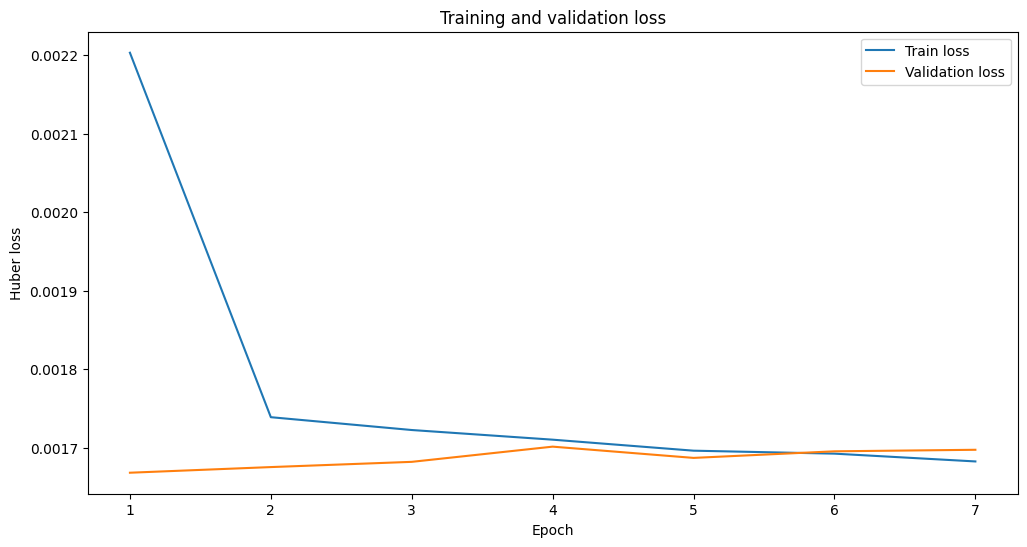

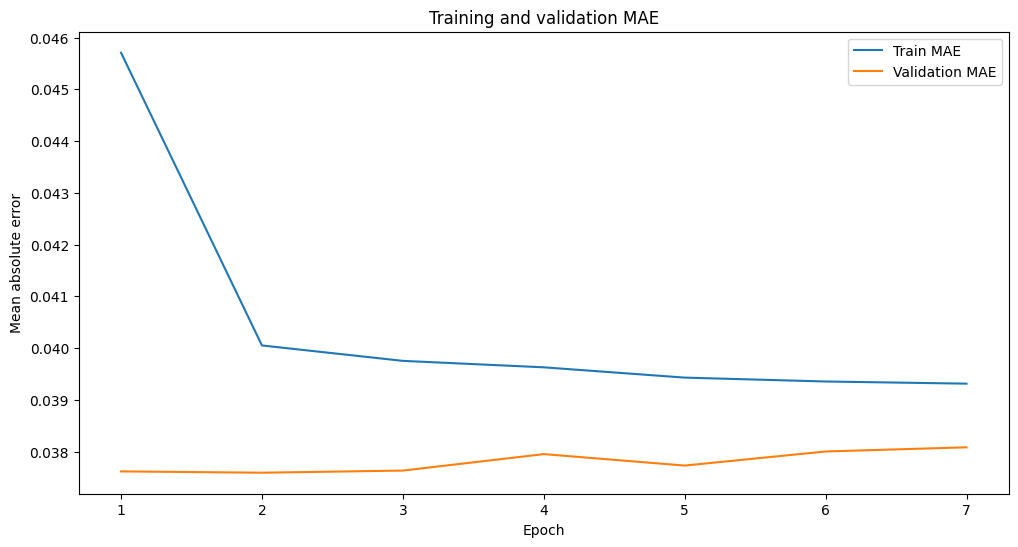

In [12]:
hist_df = pd.DataFrame(history.history)

fig, ax = plt.subplots()
ax.plot(hist_df.index + 1, hist_df["loss"], label="Train loss")
ax.plot(hist_df.index + 1, hist_df["val_loss"], label="Validation loss")
ax.set_title("Training and validation loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Huber loss")
ax.legend()
plt.show()

fig, ax = plt.subplots()
ax.plot(hist_df.index + 1, hist_df["mae"], label="Train MAE")
ax.plot(hist_df.index + 1, hist_df["val_mae"], label="Validation MAE")
ax.set_title("Training and validation MAE")
ax.set_xlabel("Epoch")
ax.set_ylabel("Mean absolute error")
ax.legend()
plt.show()

## Predictions

In [13]:
pred_train = model.predict(X_train, verbose=0).reshape(-1)
pred_val = model.predict(X_val, verbose=0).reshape(-1)
pred_test = model.predict(X_test, verbose=0).reshape(-1)

pred_all = np.empty(len(meta_all), dtype=np.float32)
pred_all[train_idx.values] = pred_train
pred_all[val_idx.values] = pred_val
pred_all[test_idx.values] = pred_test

results = meta_all.copy()
results["actual_next_ret"] = y_all
results["pred_next_ret"] = pred_all
results["pred_next_close"] = results["current_close"] * (1.0 + results["pred_next_ret"])
results["actual_direction"] = np.sign(results["actual_next_ret"])
results["pred_direction"] = np.sign(results["pred_next_ret"])
results["direction_correct"] = (results["actual_direction"] == results["pred_direction"]).astype(int)

results.head()

,symbol,date,split,current_close,next_close,actual_next_ret,pred_next_ret,pred_next_close,actual_direction,pred_direction,direction_correct
0,1000SATSUSDT,2024-12-29,train,0.000175,0.000180,0.026781,-0.000114,0.000175,1.0,-1.0,0
1,1000SATSUSDT,2024-12-30,train,0.000180,0.000179,-0.008879,-0.000986,0.000180,-1.0,-1.0,1
2,1000SATSUSDT,2024-12-31,train,0.000179,0.000180,0.008399,-0.000972,0.000178,1.0,-1.0,0
3,1000SATSUSDT,2025-01-01,train,0.000180,0.000184,0.019434,-0.001433,0.000180,1.0,-1.0,0
4,1000SATSUSDT,2025-01-02,train,0.000184,0.000193,0.051198,-0.001642,0.000183,1.0,-1.0,0


## Global test metrics

In [14]:
test_results = results[results["split"] == "test"].copy()

test_mae = mean_absolute_error(test_results["actual_next_ret"], test_results["pred_next_ret"])
test_rmse = math.sqrt(mean_squared_error(test_results["actual_next_ret"], test_results["pred_next_ret"]))
test_dir_acc = test_results["direction_correct"].mean()

print("Global test return MAE:", round(test_mae, 6))
print("Global test return RMSE:", round(test_rmse, 6))
print("Global test direction accuracy:", round(float(test_dir_acc), 4))

Global test return MAE: 0.037772
Global test return RMSE: 0.059683
Global test direction accuracy: 0.5291


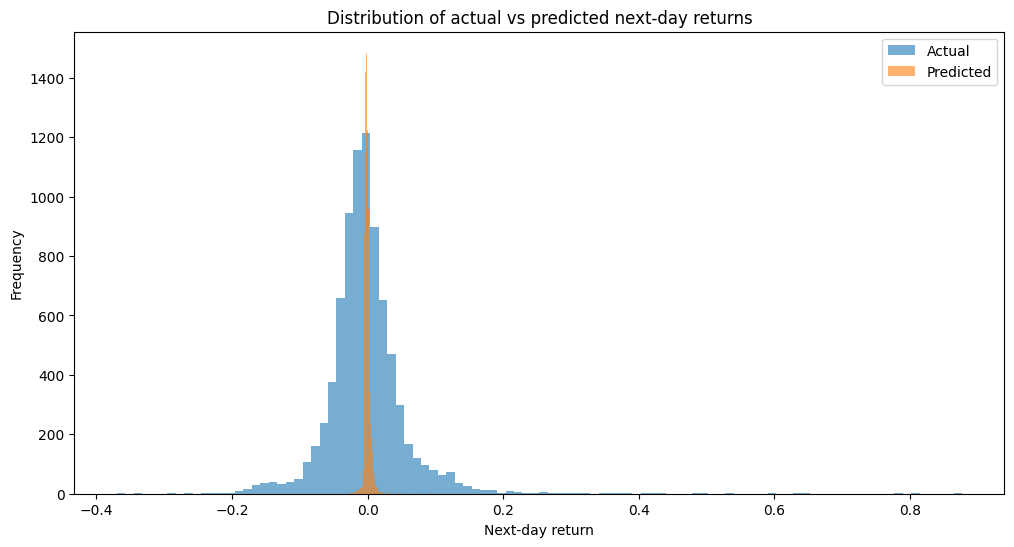

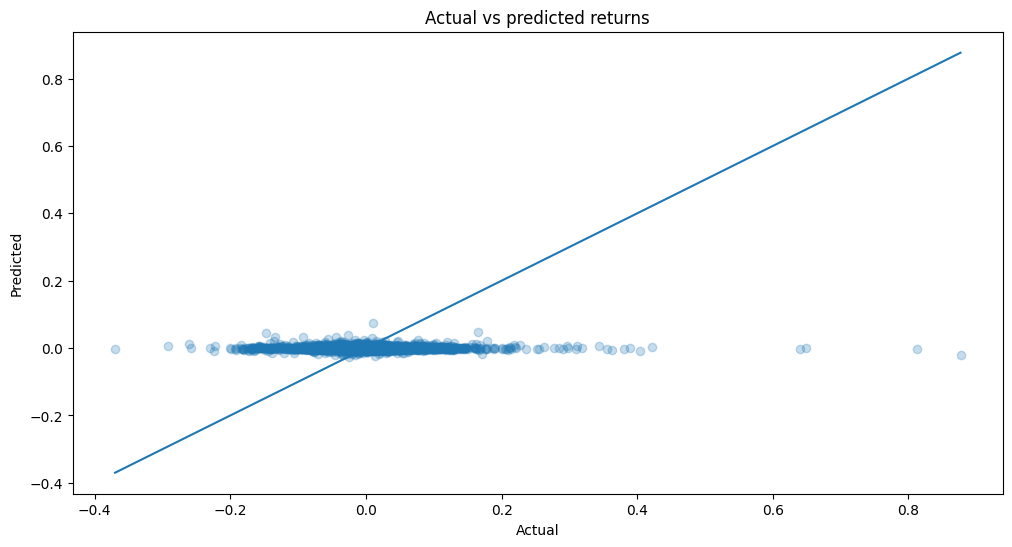

In [15]:
fig, ax = plt.subplots()
ax.hist(test_results["actual_next_ret"], bins=100, alpha=0.6, label="Actual")
ax.hist(test_results["pred_next_ret"], bins=100, alpha=0.6, label="Predicted")
ax.set_title("Distribution of actual vs predicted next-day returns")
ax.set_xlabel("Next-day return")
ax.set_ylabel("Frequency")
ax.legend()
plt.show()

sample_for_scatter = test_results.sample(min(len(test_results), 5000), random_state=SEED)
fig, ax = plt.subplots()
ax.scatter(sample_for_scatter["actual_next_ret"], sample_for_scatter["pred_next_ret"], alpha=0.25)
lims = [
    min(sample_for_scatter["actual_next_ret"].min(), sample_for_scatter["pred_next_ret"].min()),
    max(sample_for_scatter["actual_next_ret"].max(), sample_for_scatter["pred_next_ret"].max())
]
ax.plot(lims, lims)
ax.set_title("Actual vs predicted returns")
ax.set_xlabel("Actual")
ax.set_ylabel("Predicted")
plt.show()

## Target coin evaluation

In [16]:
target_results = results[results["symbol"] == TARGET_SYMBOL].sort_values("date").reset_index(drop=True)
target_test = target_results[target_results["split"] == "test"].copy().reset_index(drop=True)

print("Target test rows:", len(target_test))
target_test.head()

Target test rows: 71


,symbol,date,split,current_close,next_close,actual_next_ret,pred_next_ret,pred_next_close,actual_direction,pred_direction,direction_correct
0,BTCUSDT,2026-01-01,test,88839.039062,89995.132812,0.013013,-0.004626,88428.070312,1.0,-1.0,0
1,BTCUSDT,2026-01-02,test,89995.132812,90628.007812,0.007032,-0.004607,89580.500000,1.0,-1.0,0
2,BTCUSDT,2026-01-03,test,90628.007812,91529.726562,0.009950,-0.004779,90194.945312,1.0,-1.0,0
3,BTCUSDT,2026-01-04,test,91529.726562,93859.710938,0.025456,-0.004371,91129.687500,1.0,-1.0,0
4,BTCUSDT,2026-01-05,test,93859.710938,93747.968750,-0.001191,-0.004751,93413.789062,-1.0,-1.0,1


In [17]:
target_ret_mae = mean_absolute_error(target_test["actual_next_ret"], target_test["pred_next_ret"])
target_ret_rmse = math.sqrt(mean_squared_error(target_test["actual_next_ret"], target_test["pred_next_ret"]))
target_dir_acc = target_test["direction_correct"].mean()
target_price_mae = mean_absolute_error(target_test["next_close"], target_test["pred_next_close"])
target_price_rmse = math.sqrt(mean_squared_error(target_test["next_close"], target_test["pred_next_close"]))
target_r2 = r2_score(target_test["next_close"], target_test["pred_next_close"])

print(f"{TARGET_SYMBOL} test return MAE: {target_ret_mae:.6f}")
print(f"{TARGET_SYMBOL} test return RMSE: {target_ret_rmse:.6f}")
print(f"{TARGET_SYMBOL} direction accuracy: {target_dir_acc:.4f}")
print(f"{TARGET_SYMBOL} next-close MAE: {target_price_mae:.2f}")
print(f"{TARGET_SYMBOL} next-close RMSE: {target_price_rmse:.2f}")
print(f"{TARGET_SYMBOL} next-close R²: {target_r2:.4f}")

BTCUSDT test return MAE: 0.021717
BTCUSDT test return RMSE: 0.032717
BTCUSDT direction accuracy: 0.4507
BTCUSDT next-close MAE: 1632.35
BTCUSDT next-close RMSE: 2393.36
BTCUSDT next-close R²: 0.9546


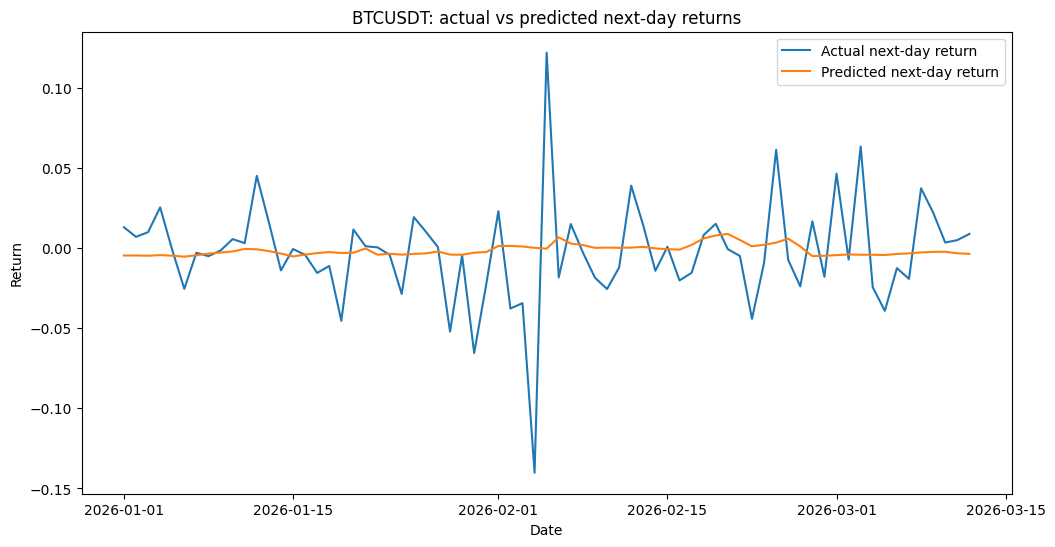

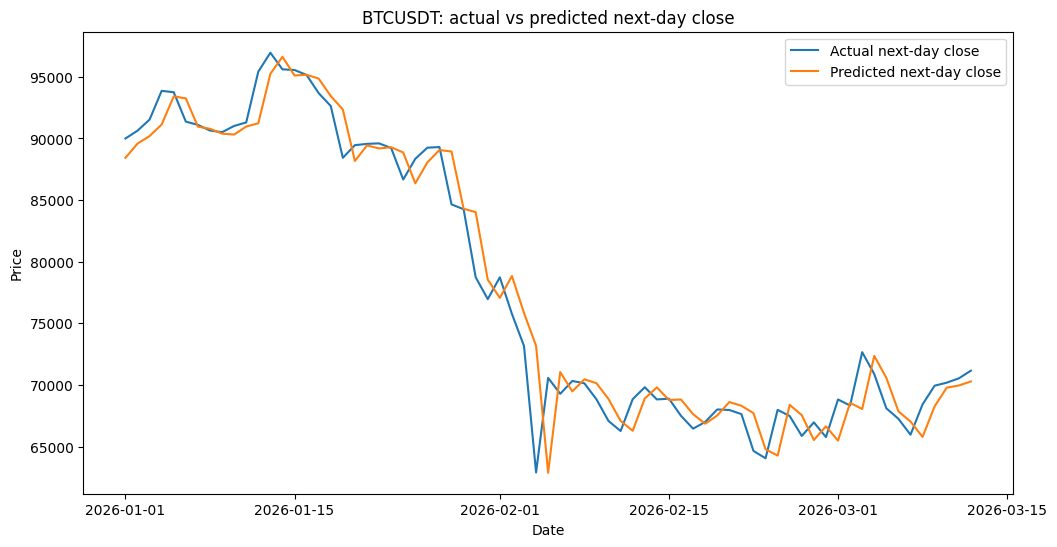

In [18]:
fig, ax = plt.subplots()
ax.plot(target_test["date"], target_test["actual_next_ret"], label="Actual next-day return")
ax.plot(target_test["date"], target_test["pred_next_ret"], label="Predicted next-day return")
ax.set_title(f"{TARGET_SYMBOL}: actual vs predicted next-day returns")
ax.set_xlabel("Date")
ax.set_ylabel("Return")
ax.legend()
plt.show()

fig, ax = plt.subplots()
ax.plot(target_test["date"], target_test["next_close"], label="Actual next-day close")
ax.plot(target_test["date"], target_test["pred_next_close"], label="Predicted next-day close")
ax.set_title(f"{TARGET_SYMBOL}: actual vs predicted next-day close")
ax.set_xlabel("Date")
ax.set_ylabel("Price")
ax.legend()
plt.show()

In [ ]:
rolling_window = 20
target_test["rolling_dir_acc"] = target_test["direction_correct"].rolling(rolling_window).mean()

fig, ax = plt.subplots()
ax.plot(target_test["date"], target_test["rolling_dir_acc"])
ax.axhline(0.5)
ax.set_title(f"{TARGET_SYMBOL}: rolling directional accuracy")
ax.set_xlabel("Date")
ax.set_ylabel("Accuracy")
plt.show()

fig, ax = plt.subplots()
ax.scatter(target_test["actual_next_ret"], target_test["pred_next_ret"], alpha=0.35)
lims = [
    min(target_test["actual_next_ret"].min(), target_test["pred_next_ret"].min()),
    max(target_test["actual_next_ret"].max(), target_test["pred_next_ret"].max())
]
ax.plot(lims, lims)
ax.set_title(f"{TARGET_SYMBOL}: actual vs predicted returns")
ax.set_xlabel("Actual")
ax.set_ylabel("Predicted")
plt.show()

## Illustrative sign strategy

This is not a production trading strategy. It is only a simple visual comparison.

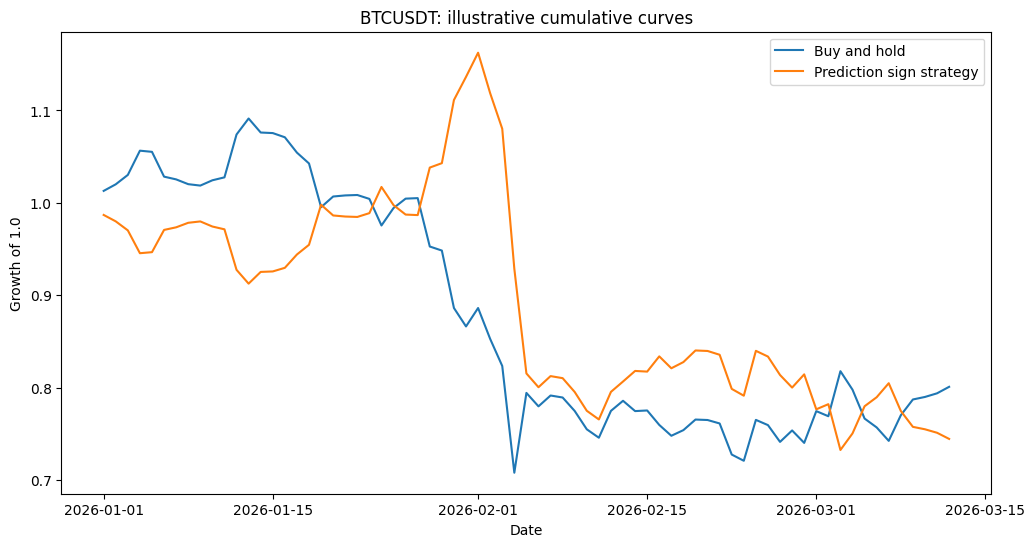

In [19]:
target_test["buy_hold_curve"] = (1.0 + target_test["actual_next_ret"]).cumprod()
target_test["signal"] = np.where(target_test["pred_next_ret"] > 0, 1.0, -1.0)
target_test["strategy_ret"] = target_test["signal"] * target_test["actual_next_ret"]
target_test["strategy_curve"] = (1.0 + target_test["strategy_ret"]).cumprod()

fig, ax = plt.subplots()
ax.plot(target_test["date"], target_test["buy_hold_curve"], label="Buy and hold")
ax.plot(target_test["date"], target_test["strategy_curve"], label="Prediction sign strategy")
ax.set_title(f"{TARGET_SYMBOL}: illustrative cumulative curves")
ax.set_xlabel("Date")
ax.set_ylabel("Growth of 1.0")
ax.legend()
plt.show()

## Save artifacts

In [ ]:
from pathlib import Path
import joblib

out_dir = Path("artifacts_crypto_panel_model")
out_dir.mkdir(exist_ok=True)

model.save(out_dir / "keras_multi_coin_model.keras")
joblib.dump(scaler, out_dir / "feature_scaler.joblib")
target_test.to_csv(out_dir / f"{TARGET_SYMBOL.lower()}_test_predictions.csv", index=False)
results.to_csv(out_dir / "all_predictions.csv", index=False)

print("Saved files:")
for p in sorted(out_dir.glob("*")):
    print("-", p)